## Notebook 07 — Latency & Throughput
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** End-to-end inference latency and theoretical throughput benchmarking for RF and MLP pipelines


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import pickle
import time
from PIL import Image
from scipy.ndimage import gaussian_filter
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import sys
sys.path.insert(0, os.path.abspath('..'))

In [2]:
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
DATASET_PATH = os.path.join('..', 'datasets', 'dataset-resized')
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')
IMAGE_SIZE = (224, 224)
HISTOGRAM_BINS = 32

In [3]:
with open(os.path.join(RESULTS_PATH, 'rf_final_model.pkl'), 'rb') as f:
    rf_model = pickle.load(f)

with open(os.path.join(RESULTS_PATH, 'mlp_final_model.pkl'), 'rb') as f:
    mlp_model = pickle.load(f)

with open(os.path.join(RESULTS_PATH, 'mlp_scaler.pkl'), 'rb') as f:
    mlp_scaler = pickle.load(f)

In [4]:
# Defines the feature extraction pipeline used as the timed first stage of each inference pipeline

from src.features import extract_features_from_image as extract_features


In [5]:
# Loads one representative image per class to use as samples for latency timing

sample_images = []
sample_labels = []

for class_name in CLASSES:
    class_folder = os.path.join(DATASET_PATH, class_name)
    img_file = sorted(os.listdir(class_folder))[0]
    img_path = os.path.join(class_folder, img_file)
    image = Image.open(img_path).convert('RGB')
    sample_images.append(image)
    sample_labels.append(class_name)

print(f"Loaded {len(sample_images)} sample images for benchmarking")
print("Sample classes:", sample_labels)

Loaded 6 sample images for benchmarking
Sample classes: ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']


In [6]:
# Benchmarks feature extraction latency by averaging over N_REPEATS timed calls per sample image

N_REPEATS = 200

extraction_times = []

for image in sample_images:
    times = []
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        features = extract_features(image)
        end = time.perf_counter()
        times.append(end - start)
    extraction_times.append(np.mean(times))

mean_extraction_ms = np.mean(extraction_times) * 1000
std_extraction_ms  = np.std(extraction_times) * 1000

print(f"Feature extraction latency:")
print(f"  Mean : {mean_extraction_ms:.3f} ms")
print(f"  Std  : {std_extraction_ms:.3f} ms")
print(f"  Min  : {min(extraction_times)*1000:.3f} ms")
print(f"  Max  : {max(extraction_times)*1000:.3f} ms")

Feature extraction latency:
  Mean : 18.152 ms
  Std  : 0.124 ms
  Min  : 17.915 ms
  Max  : 18.339 ms


In [7]:
# Pre-computes feature vectors for all samples, then measures RF and MLP classification latency independently over repeated calls

sample_features = np.array([extract_features(img) for img in sample_images])
sample_features_scaled = mlp_scaler.transform(sample_features)

print(f"Sample features shape: {sample_features.shape}")

rf_times = []
for i in range(len(sample_images)):
    times = []
    feature_vector = sample_features[i].reshape(1, -1)
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        prediction = rf_model.predict(feature_vector)
        end = time.perf_counter()
        times.append(end - start)
    rf_times.append(np.mean(times))

mean_rf_ms = np.mean(rf_times) * 1000
std_rf_ms  = np.std(rf_times) * 1000

print(f"\nRF classification latency:")
print(f"  Mean : {mean_rf_ms:.4f} ms")
print(f"  Std  : {std_rf_ms:.4f} ms")

mlp_times = []
for i in range(len(sample_images)):
    times = []
    feature_vector = sample_features_scaled[i].reshape(1, -1)
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        prediction = mlp_model.predict(feature_vector)
        end = time.perf_counter()
        times.append(end - start)
    mlp_times.append(np.mean(times))

mean_mlp_ms = np.mean(mlp_times) * 1000
std_mlp_ms  = np.std(mlp_times) * 1000

print(f"\nMLP classification latency:")
print(f"  Mean : {mean_mlp_ms:.4f} ms")
print(f"  Std  : {std_mlp_ms:.4f} ms")

Sample features shape: (6, 122)



RF classification latency:
  Mean : 38.9877 ms
  Std  : 1.9884 ms

MLP classification latency:
  Mean : 0.1048 ms
  Std  : 0.0006 ms


In [8]:
# Combines extraction and classification latencies to compute end-to-end pipeline latency, theoretical throughput, and items-per-minute figures

rf_e2e_ms  = mean_extraction_ms + mean_rf_ms
mlp_e2e_ms = mean_extraction_ms + mean_mlp_ms

print("=== End to End Latency ===")
print(f"\nRF pipeline:")
print(f"  Feature extraction : {mean_extraction_ms:.3f} ms")
print(f"  Classification     : {mean_rf_ms:.4f} ms")
print(f"  Total e2e latency  : {rf_e2e_ms:.3f} ms")

print(f"\nMLP pipeline:")
print(f"  Feature extraction : {mean_extraction_ms:.3f} ms")
print(f"  Scaling            : ~0.01 ms (negligible)")
print(f"  Classification     : {mean_mlp_ms:.4f} ms")
print(f"  Total e2e latency  : {mlp_e2e_ms:.3f} ms")

rf_throughput  = 1000 / rf_e2e_ms
mlp_throughput = 1000 / mlp_e2e_ms

print(f"\n=== Theoretical Throughput ===")
print(f"  RF  : {rf_throughput:.2f}  images/second")
print(f"  MLP : {mlp_throughput:.2f} images/second")

rf_ipm  = rf_throughput  * 60
mlp_ipm = mlp_throughput * 60

print(f"\n  RF  : {rf_ipm:.1f}  items/minute")
print(f"  MLP : {mlp_ipm:.1f} items/minute")

import json
latency_results = {
    'feature_extraction_ms': mean_extraction_ms,
    'feature_extraction_std_ms': std_extraction_ms,
    'rf_classification_ms': mean_rf_ms,
    'rf_classification_std_ms': std_rf_ms,
    'mlp_classification_ms': mean_mlp_ms,
    'mlp_classification_std_ms': std_mlp_ms,
    'rf_e2e_ms': rf_e2e_ms,
    'mlp_e2e_ms': mlp_e2e_ms,
    'rf_throughput_per_second': rf_throughput,
    'mlp_throughput_per_second': mlp_throughput,
    'rf_throughput_per_minute': rf_ipm,
    'mlp_throughput_per_minute': mlp_ipm
}

with open(os.path.join(RESULTS_PATH, 'latency_results.json'), 'w') as f:
    json.dump(latency_results, f, indent=2)

print(f"\nLatency results saved.")

=== End to End Latency ===

RF pipeline:
  Feature extraction : 18.152 ms
  Classification     : 38.9877 ms
  Total e2e latency  : 57.140 ms

MLP pipeline:
  Feature extraction : 18.152 ms
  Scaling            : ~0.01 ms (negligible)
  Classification     : 0.1048 ms
  Total e2e latency  : 18.257 ms

=== Theoretical Throughput ===
  RF  : 17.50  images/second
  MLP : 54.77 images/second

  RF  : 1050.1  items/minute
  MLP : 3286.5 items/minute

Latency results saved.


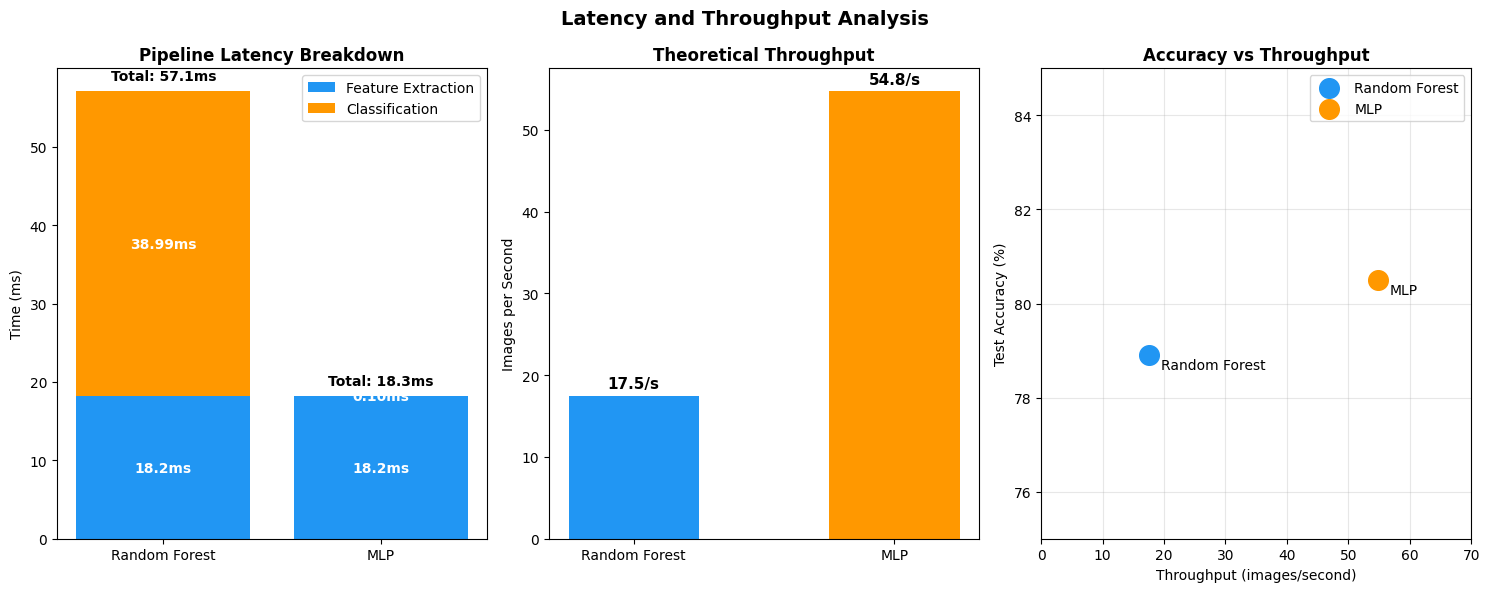

Latency plot saved.


In [9]:
# Three-panel figure: pipeline latency breakdown, throughput comparison, and accuracy-vs-throughput scatter plot

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

categories = ['Random Forest', 'MLP']
extraction_times_plot = [mean_extraction_ms, mean_extraction_ms]
classification_times_plot = [mean_rf_ms, mean_mlp_ms]

bars1 = axes[0].bar(categories, extraction_times_plot,
                    color='#2196F3', label='Feature Extraction')
bars2 = axes[0].bar(categories, classification_times_plot,
                    bottom=extraction_times_plot,
                    color='#FF9800', label='Classification')

axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Pipeline Latency Breakdown', fontweight='bold')
axes[0].legend()

for i, (e, c) in enumerate(zip(extraction_times_plot, classification_times_plot)):
    axes[0].text(i, e/2, f'{e:.1f}ms', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)
    axes[0].text(i, e + c/2, f'{c:.2f}ms', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

for i, total in enumerate([rf_e2e_ms, mlp_e2e_ms]):
    axes[0].text(i, total + 1, f'Total: {total:.1f}ms',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

models = ['Random Forest', 'MLP']
throughputs = [rf_throughput, mlp_throughput]
colours = ['#2196F3', '#FF9800']

bars = axes[1].bar(models, throughputs, color=colours, width=0.5)
axes[1].set_ylabel('Images per Second')
axes[1].set_title('Theoretical Throughput', fontweight='bold')

for bar, val in zip(bars, throughputs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}/s', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

axes[2].scatter(rf_throughput, 78.9, s=200, color='#2196F3',
               zorder=5, label='Random Forest')
axes[2].scatter(mlp_throughput, 80.5, s=200, color='#FF9800',
               zorder=5, label='MLP')

axes[2].annotate('Random Forest',
                xy=(rf_throughput, 78.9),
                xytext=(rf_throughput + 2, 78.6),
                fontsize=10)
axes[2].annotate('MLP',
                xy=(mlp_throughput, 80.5),
                xytext=(mlp_throughput + 2, 80.2),
                fontsize=10)

axes[2].set_xlabel('Throughput (images/second)')
axes[2].set_ylabel('Test Accuracy (%)')
axes[2].set_title('Accuracy vs Throughput', fontweight='bold')
axes[2].set_xlim(0, 70)
axes[2].set_ylim(75, 85)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle('Latency and Throughput Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'latency_throughput.png'), dpi=150)
plt.show()
print("Latency plot saved.")

In [10]:
print(f"\nFeature Extraction:")
print(f"  Mean latency : {mean_extraction_ms:.3f} ms (+/- {std_extraction_ms:.3f} ms)")

print(f"\nClassification Latency:")
print(f"  RF  : {mean_rf_ms:.4f} ms (+/- {std_rf_ms:.4f} ms)")
print(f"  MLP : {mean_mlp_ms:.4f} ms (+/- {std_mlp_ms:.4f} ms)")
print(f"  RF/MLP ratio : {mean_rf_ms/mean_mlp_ms:.1f}x slower")

print(f"\nEnd to End Latency:")
print(f"  RF  : {rf_e2e_ms:.3f} ms")
print(f"  MLP : {mlp_e2e_ms:.3f} ms")
print(f"  RF/MLP ratio : {rf_e2e_ms/mlp_e2e_ms:.2f}x slower")

print(f"\nThroughput:")
print(f"  RF  : {rf_throughput:.2f} images/second | {rf_ipm:.1f} items/minute")
print(f"  MLP : {mlp_throughput:.2f} images/second | {mlp_ipm:.1f} items/minute")


Feature Extraction:
  Mean latency : 18.152 ms (+/- 0.124 ms)

Classification Latency:
  RF  : 38.9877 ms (+/- 1.9884 ms)
  MLP : 0.1048 ms (+/- 0.0006 ms)
  RF/MLP ratio : 372.1x slower

End to End Latency:
  RF  : 57.140 ms
  MLP : 18.257 ms
  RF/MLP ratio : 3.13x slower

Throughput:
  RF  : 17.50 images/second | 1050.1 items/minute
  MLP : 54.77 images/second | 3286.5 items/minute
